# TUGAS 1-A

## Daniel Bara Seftino | 5026231169 | 2026-PBA-GENAP

# Libraries Instalation

Apabila sudah install bisa di comment

In [ ]:
# !pip install google_play_scraper
# !pip install textblob
# !pip install seaborn
# !pip install nltk
# !pip install Sastrawi
# !pip install matplotlib

# Data Collection

## Initial Setup

In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
import nltk
from collections import Counter
from nltk.tokenize import word_tokenize
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import CountVectorizer

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

Data Source, Android App Livin' by Mandiri from Google Play at "https://play.google.com/store/apps/details?id=id.bmri.livin"

In [3]:
import os
from pathlib import Path
from google_play_scraper import app, Sort, reviews_all

# Notebook ada di week-1/, CSV ada di ../data/
CSV_PATH = Path("../data/livinByMandiri_rev_raw.csv")

data_from_csv = CSV_PATH.exists()

if data_from_csv:
    print(f"CSV ditemukan! Loading data dari {CSV_PATH.resolve()}...")
    df_reviews = pd.read_csv(CSV_PATH)
    print(f"Berhasil load {len(df_reviews)} reviews dari CSV.")
else:
    print("CSV tidak ditemukan. Melakukan scraping dari Google Play Store...")
    livin_reviews = reviews_all(
        'id.bmri.livin',
        sleep_milliseconds=0,
        lang='id',
        country='id',
        sort=Sort.NEWEST,
    )
    df_reviews = pd.DataFrame(livin_reviews)
    print(f"Berhasil scrape {len(df_reviews)} reviews.")

df_reviews.head()

CSV ditemukan! Loading data dari C:\Users\Bara\OneDrive\Documents\Tugas\PBA\pba-task-1a-individual\data\livinByMandiri_rev_raw.csv...
Berhasil load 281691 reviews dari CSV.


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,07609bd6-ebb7-4355-a925-460d84128481,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,Tiap akhir bulan livin nya gangguan dann tidak...,1,0,3.2.0,2026-02-27 12:59:32,"Halo Sahabat @Sapuan, mohon maaf atas ketidakn...",2026-02-27 13:23:40,3.2.0
1,c4a65798-4dff-4169-9671-3b4082abfa7d,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,salesnya penipu,1,0,NaN,2026-02-27 12:57:44,"Halo Sahabat @Iqbal Maulana, mohon maaf atas k...",2026-02-27 13:03:00,NaN
2,49d27a12-451b-448a-97a6-c93583b75b8b,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,tolong dong di kasih nada special kalau pas ad...,3,0,NaN,2026-02-27 12:47:55,"Halo Sahabat @Aku Umi, mohon maaf atas ketidak...",2026-02-27 12:51:49,NaN
3,9d1a6b0f-50cd-4d64-8ca1-3c37bca42459,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,saya kena RPT02 udh 3 cabang blom bisa² login ...,1,0,1.9.0,2026-02-27 12:41:30,"Halo Sahabat @Hendri pratama, mohon maaf atas ...",2026-02-27 12:44:32,1.9.0
4,09400c18-3aca-438f-8e6e-340731dd7781,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat baik dan membantu,5,0,3.2.0,2026-02-27 12:28:54,"Halo Sahabat @Subekti Wijaya, terima kasih ata...",2026-02-27 12:32:44,3.2.0


In [4]:
df_livinReview = df_reviews

## Save data into DataFrame (df_livinReview)

In [5]:
df_livinReview = df_reviews.copy()

# Hanya masking jika data baru di-scrape (bukan dari CSV yang sudah dimasking)
if not data_from_csv:
    def mask_username(username):
        if pd.isna(username):
            return username
        username = str(username)
        if len(username) <= 4:
            return "*" * len(username)
        return username[:2] + "*" * (len(username)-4) + username[-2:]

    df_livinReview['userName'] = df_livinReview['userName'].apply(mask_username)
    print("Username masking applied.")
else:
    print("Data dari CSV, username sudah di-mask sebelumnya.")

Data dari CSV, username sudah di-mask sebelumnya.


In [6]:
if not data_from_csv:
    os.makedirs("data", exist_ok=True)
    df_livinReview.to_csv(CSV_PATH, index=False)
    print(f"Data disimpan ke {CSV_PATH}")
else:
    print("Data sudah berasal dari CSV, skip penyimpanan.")

Data sudah berasal dari CSV, skip penyimpanan.


In [7]:
df_livinReview

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,07609bd6-ebb7-4355-a925-460d84128481,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,Tiap akhir bulan livin nya gangguan dann tidak...,1,0,3.2.0,2026-02-27 12:59:32,"Halo Sahabat @Sapuan, mohon maaf atas ketidakn...",2026-02-27 13:23:40,3.2.0
1,c4a65798-4dff-4169-9671-3b4082abfa7d,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,salesnya penipu,1,0,NaN,2026-02-27 12:57:44,"Halo Sahabat @Iqbal Maulana, mohon maaf atas k...",2026-02-27 13:03:00,NaN
2,49d27a12-451b-448a-97a6-c93583b75b8b,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,tolong dong di kasih nada special kalau pas ad...,3,0,NaN,2026-02-27 12:47:55,"Halo Sahabat @Aku Umi, mohon maaf atas ketidak...",2026-02-27 12:51:49,NaN
3,9d1a6b0f-50cd-4d64-8ca1-3c37bca42459,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,saya kena RPT02 udh 3 cabang blom bisa² login ...,1,0,1.9.0,2026-02-27 12:41:30,"Halo Sahabat @Hendri pratama, mohon maaf atas ...",2026-02-27 12:44:32,1.9.0
4,09400c18-3aca-438f-8e6e-340731dd7781,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,Sangat baik dan membantu,5,0,3.2.0,2026-02-27 12:28:54,"Halo Sahabat @Subekti Wijaya, terima kasih ata...",2026-02-27 12:32:44,3.2.0
...,...,...,...,...,...,...,...,...,...,...,...
281686,40fc5bf0-6aa5-489c-9db9-92989057d498,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,Mantap,5,0,1.0.0,2021-09-30 14:02:21,Halo Bpk Apri terima kasih atas review yang te...,2021-09-30 14:48:49,1.0.0
281687,e064d767-256a-4b47-8b34-af82ef7b1d81,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,NaN,2021-09-30 13:56:05,Terima kasih atas review yang telah diberikan ...,2021-09-30 14:48:02,NaN
281688,40d443c4-ab6a-446a-be28-2aebc7efad62,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,Keren. Cakep benar semakin canggih. Terdepan t...,5,22,1.0.0,2021-09-30 13:48:30,Terima kasih atas review yang telah diberikan ...,2021-09-30 14:15:22,1.0.0
281689,867eb0a4-f14e-4f33-8aff-c8a2f1ce098e,Pe***********le,https://play-lh.googleusercontent.com/EGemoI2N...,Excellent,5,0,1.0.0,2021-09-30 13:33:15,Thank you for the review provided by Mrs Afnin...,2021-09-30 14:06:25,1.0.0


In [8]:
df_livinReview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 281691 entries, 0 to 281690
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              281691 non-null  object
 1   userName              281691 non-null  object
 2   userImage             281691 non-null  object
 3   content               281691 non-null  object
 4   score                 281691 non-null  int64 
 5   thumbsUpCount         281691 non-null  int64 
 6   reviewCreatedVersion  220905 non-null  object
 7   at                    281691 non-null  object
 8   replyContent          277258 non-null  object
 9   repliedAt             277258 non-null  object
 10  appVersion            220905 non-null  object
dtypes: int64(2), object(9)
memory usage: 23.6+ MB


# Data Preprocessing

## 1. Lowercasing

In [9]:
# Copy original DataFrame agar data asli tetap aman
df_lowercased = df_livinReview.copy()
df_lowercased['content'] = df_lowercased['content'].astype(str)

print("Before lowercase:")
print(df_lowercased['content'].head())

# Apply lowercasing
df_lowercased['content'] = df_lowercased['content'].str.lower()

print("\nAfter lowercase:")
print(df_lowercased['content'].head())
print(f"\nShape: {df_lowercased.shape}")

Before lowercase:
0    Tiap akhir bulan livin nya gangguan dann tidak...
1                                      salesnya penipu
2    tolong dong di kasih nada special kalau pas ad...
3    saya kena RPT02 udh 3 cabang blom bisa² login ...
4                             Sangat baik dan membantu
Name: content, dtype: object

After lowercase:
0    tiap akhir bulan livin nya gangguan dann tidak...
1                                      salesnya penipu
2    tolong dong di kasih nada special kalau pas ad...
3    saya kena rpt02 udh 3 cabang blom bisa² login ...
4                             sangat baik dan membantu
Name: content, dtype: object

Shape: (281691, 11)


## 2. Punctuation Removal

Menghapus tanda baca agar tidak mengganggu proses tokenisasi dan analisis frekuensi kata.

In [10]:
import re

df_cleaned = df_lowercased.copy()

print("Before punctuation removal:")
print(df_cleaned['content'].head())

# Remove all punctuation (keep only alphanumeric and whitespace)
df_cleaned['content'] = df_cleaned['content'].apply(lambda x: re.sub(r'[^\w\s]', '', str(x)))

# Remove extra whitespace
df_cleaned['content'] = df_cleaned['content'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("\nAfter punctuation removal:")
print(df_cleaned['content'].head())
print(f"\nShape: {df_cleaned.shape}")

Before punctuation removal:
0    tiap akhir bulan livin nya gangguan dann tidak...
1                                      salesnya penipu
2    tolong dong di kasih nada special kalau pas ad...
3    saya kena rpt02 udh 3 cabang blom bisa² login ...
4                             sangat baik dan membantu
Name: content, dtype: object

After punctuation removal:
0    tiap akhir bulan livin nya gangguan dann tidak...
1                                      salesnya penipu
2    tolong dong di kasih nada special kalau pas ad...
3    saya kena rpt02 udh 3 cabang blom bisa² login ...
4                             sangat baik dan membantu
Name: content, dtype: object

Shape: (281691, 11)


## 3. Tokenization

In [11]:
from nltk.tokenize import word_tokenize
from collections import Counter

df_tokenized = df_cleaned.copy()
df_tokenized['tokens'] = df_tokenized['content'].apply(word_tokenize)

# Hitung frekuensi token
all_tokens = [token for tokens in df_tokenized['tokens'] for token in tokens]
token_counts = Counter(all_tokens)
top_50 = token_counts.most_common(50)

print("Top 50 most common tokens (after punctuation removal):")
print(top_50)
print(f"\nTotal unique tokens: {len(token_counts)}")
print(f"Shape: {df_tokenized.shape}")

Top 50 most common tokens (after punctuation removal):
[('bisa', 60120), ('di', 57481), ('saya', 42755), ('livin', 39827), ('sangat', 39224), ('aplikasi', 38799), ('dan', 33131), ('ini', 32883), ('tidak', 32076), ('mandiri', 28471), ('nya', 26926), ('bagus', 26034), ('update', 24334), ('yg', 23382), ('ada', 23113), ('mau', 22753), ('gak', 21688), ('transaksi', 21046), ('membantu', 20900), ('kenapa', 19790), ('ga', 18264), ('ke', 17945), ('lagi', 16560), ('terus', 15491), ('sudah', 15371), ('mantap', 15227), ('untuk', 15158), ('lebih', 15057), ('yang', 14700), ('mudah', 14302), ('buka', 13106), ('aja', 13068), ('ya', 13030), ('sering', 12867), ('login', 12690), ('bank', 12554), ('susah', 12378), ('tapi', 12319), ('tolong', 12254), ('malah', 11971), ('masuk', 11739), ('ok', 11484), ('padahal', 10908), ('harus', 10487), ('buat', 10480), ('udah', 10193), ('saldo', 9988), ('jadi', 9920), ('banget', 9830), ('gagal', 9780)]

Total unique tokens: 86514
Shape: (281691, 12)


## 4. Slang Normalization

Normalisasi kata-kata slang/singkatan ke bentuk baku **sebelum** stopword removal, agar kata seperti `gak`→`tidak`, `yg`→`yang` bisa dikenali sebagai stopword dan dihapus di step berikutnya.

In [12]:
# Slang mapping (expanded for Livin' by Mandiri app reviews)
slang_dict = {
    # === Negasi / Penolakan ===
    "ngga": "tidak",
    "ga": "tidak",
    "gak": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "nggk": "tidak",
    "gaa": "tidak",
    "gaaa": "tidak",
    "engga": "tidak",
    "enggak": "tidak",
    "kagak": "tidak",
    "kgk": "tidak",
    "tdk": "tidak",
    "ngk": "tidak",
    "ndak": "tidak",
    "gabisa": "tidak bisa",
    "gaisa": "tidak bisa",
    "gbs": "tidak bisa",
    "gbsa": "tidak bisa",
    "gamau": "tidak mau",
    "gamo": "tidak mau",
    "gabisaa": "tidak bisa",
    "gatau": "tidak tahu",
    "gatauu": "tidak tahu",

    # === Singkatan Umum ===
    "yg": "yang",
    "tp": "tapi",
    "tpi": "tapi",
    "utk": "untuk",
    "tuk": "untuk",
    "ntk": "untuk",
    "krn": "karena",
    "krna": "karena",
    "karna": "karena",
    "dgn": "dengan",
    "dg": "dengan",
    "dng": "dengan",
    "dr": "dari",
    "dri": "dari",
    "pd": "pada",
    "sm": "sama",
    "sma": "sama",
    "jg": "juga",
    "jga": "juga",
    "jd": "jadi",
    "jdi": "jadi",
    "sdh": "sudah",
    "sdg": "sedang",
    "blm": "belum",
    "blom": "belum",
    "belom": "belum",
    "blum": "belum",
    "msh": "masih",
    "masi": "masih",
    "msih": "masih",
    "lg": "lagi",
    "lgi": "lagi",
    "dl": "dulu",
    "dlu": "dulu",
    "bs": "bisa",
    "bsa": "bisa",
    "hrs": "harus",
    "hrus": "harus",
    "spy": "supaya",
    "spya": "supaya",
    "spt": "seperti",
    "sprti": "seperti",
    "kyk": "seperti",
    "ky": "kayak",
    "klo": "kalau",
    "klu": "kalau",
    "kl": "kalau",
    "kalo": "kalau",
    "klw": "kalau",
    "klau": "kalau",
    "klaw": "kalau",

    # === Kata Ganti / Sapaan ===
    "gw": "saya",
    "gue": "saya",
    "gua": "saya",
    "ane": "saya",
    "ak": "saya",
    "sy": "saya",
    "aq": "saya",
    "lo": "kamu",
    "lu": "kamu",
    "loe": "kamu",
    "elu": "kamu",
    "ente": "kamu",

    # === Kata Keterangan / Sifat ===
    "bgt": "banget",
    "bgtt": "banget",
    "bngt": "banget",
    "bner": "benar",
    "bnr": "benar",
    "sgt": "sangat",
    "sngat": "sangat",
    "skrg": "sekarang",
    "skr": "sekarang",
    "skrang": "sekarang",
    "td": "tadi",
    "tdi": "tadi",
    "trs": "terus",
    "trus": "terus",
    "truss": "terus",
    "trz": "terus",
    "cuma": "hanya",
    "cmn": "hanya",
    "cman": "hanya",
    "doang": "saja",
    "doank": "saja",
    "aja": "saja",
    "aj": "saja",
    "ajaa": "saja",
    "ajah": "saja",
    "emg": "memang",
    "emng": "memang",
    "emang": "memang",
    "mmg": "memang",
    "smpe": "sampai",
    "sampe": "sampai",
    "smpai": "sampai",
    "smpi": "sampai",
    "ampe": "sampai",
    "plg": "paling",
    "pling": "paling",

    # === Kata Tanya ===
    "knp": "kenapa",
    "knpa": "kenapa",
    "npa": "kenapa",
    "ap": "apa",
    "apaa": "apa",
    "apaan": "apa",
    "gmn": "bagaimana",
    "gmna": "bagaimana",
    "gimana": "bagaimana",
    "dmn": "dimana",
    "dmna": "dimana",
    "dimn": "dimana",
    "kmn": "kemana",
    "kmna": "kemana",
    "kemn": "kemana",
    "brp": "berapa",
    "brpa": "berapa",
    "kpn": "kapan",

    # === Kata Kerja Informal ===
    "udah": "sudah",
    "udh": "sudah",
    "uda": "sudah",
    "dah": "sudah",
    "milih": "pilih",
    "nyoba": "coba",
    "nyobain": "coba",
    "ngapain": "mengapa",
    "ngeluh": "mengeluh",
    "ngerti": "mengerti",
    "ngecek": "mengecek",
    "ngebug": "bug",
    "ngehang": "hang",
    "ngelag": "lambat",
    "ngasih": "memberi",
    "ngirim": "mengirim",
    "ngisi": "mengisi",
    "nunggu": "menunggu",
    "nyuruh": "menyuruh",
    "bikin": "membuat",
    "bkin": "membuat",
    "ngomong": "berbicara",
    "nanya": "bertanya",
    "naro": "meletakkan",
    "masukin": "masukkan",
    "uninstal": "uninstall",

    # === Respon / Ekspresi ===
    "oke": "baik",
    "ok": "baik",
    "okee": "baik",
    "okey": "baik",
    "oks": "baik",
    "sip": "baik",
    "siap": "baik",
    "makasih": "terima kasih",
    "makasi": "terima kasih",
    "mksh": "terima kasih",
    "trims": "terima kasih",
    "thx": "terima kasih",
    "thanks": "terima kasih",
    "tq": "terima kasih",
    "mantep": "mantap",
    "mantab": "mantap",
    "mantul": "mantap betul",
    "mantp": "mantap",
    "gpp": "tidak apa-apa",
    "gppa": "tidak apa-apa",
    "gapapa": "tidak apa-apa",

    # === Konteks Banking / Fintech ===
    "tf": "transfer",
    "trf": "transfer",
    "trnsfer": "transfer",
    "trx": "transaksi",
    "rek": "rekening",
    "mbank": "mobile banking",
    "mbanking": "mobile banking",
    "ebanking": "electronic banking",
    "ibank": "internet banking",
    "ibanking": "internet banking",
    "verif": "verifikasi",
    "verifkasi": "verifikasi",
    "nomer": "nomor",
    "nmr": "nomor",
    "pwd": "password",
    "pw": "password",
    "sldo": "saldo",
    "brhasil": "berhasil",
    "notif": "notifikasi",
    "notip": "notifikasi",

    # === Masalah App / Teknis ===
    "eror": "error",
    "erorr": "error",
    "eroor": "error",
    "erornya": "error",
    "lemot": "lambat",
    "lemoot": "lambat",
    "lmot": "lambat",
    "lelet": "lambat",
    "lag": "lambat",
    "heng": "hang",
    "ngeheng": "hang",
    "fc": "force close",
    "frc": "force close",
    "apk": "aplikasi",
    "aplksi": "aplikasi",
    "apl": "aplikasi",
    "app": "aplikasi",
    "apli": "aplikasi",
    "appnya": "aplikasi",
    "appsnya": "aplikasi",
    "applikasi": "aplikasi",

    # === Misc / Lainnya ===
    "bbrp": "beberapa",
    "brg": "barang",
    "org": "orang",
    "org2": "orang-orang",
    "tgl": "tanggal",
    "bln": "bulan",
    "thn": "tahun",
    "rb": "ribu",
    "jt": "juta",
    "jth": "juta",
    "duit": "uang",
    "doi": "dia",
    "mrk": "mereka",
    "smua": "semua",
    "smuanya": "semuanya",
    "byk": "banyak",
    "bnyk": "banyak",
    "sdikit": "sedikit",
    "sdkit": "sedikit",
    "dkit": "sedikit",
    "dikit": "sedikit",
    "tiap": "setiap",
    "stiap": "setiap",
    "bgus": "bagus",
    "bgs": "bagus",
    "jlk": "buruk",
    "pdhl": "padahal",
    "pdhal": "padahal",
    "btuh": "butuh",
    "pke": "pakai",
    "pake": "pakai",
    "pkek": "pakai",
}

print(f"Total slang entries: {len(slang_dict)}")

Total slang entries: 261


In [13]:
def normalize_slang(tokens):
    """Replace slang tokens with standard form. Handles multi-word replacements."""
    result = []
    for t in tokens:
        if t in slang_dict:
            replacement = slang_dict[t]
            # Handle multi-word replacements (e.g. 'gabisa' -> 'tidak bisa')
            result.extend(replacement.split())
        else:
            result.append(t)
    return result

df_normalized = df_tokenized.copy()
df_normalized['tokens'] = df_normalized['tokens'].apply(normalize_slang)

# Show comparison
print("=== Before Slang Normalization ===")
print(df_tokenized['tokens'].head(5).to_string())
print("\n=== After Slang Normalization ===")
print(df_normalized['tokens'].head(5).to_string())
print(f"\nShape: {df_normalized.shape}")

=== Before Slang Normalization ===
0    [tiap, akhir, bulan, livin, nya, gangguan, dan...
1                                   [salesnya, penipu]
2    [tolong, dong, di, kasih, nada, special, kalau...
3    [saya, kena, rpt02, udh, 3, cabang, blom, bisa...
4                        [sangat, baik, dan, membantu]

=== After Slang Normalization ===
0    [setiap, akhir, bulan, livin, nya, gangguan, d...
1                                   [salesnya, penipu]
2    [tolong, dong, di, kasih, nada, special, kalau...
3    [saya, kena, rpt02, sudah, 3, cabang, belum, b...
4                        [sangat, baik, dan, membantu]

Shape: (281691, 12)


## 5. Stopword Removal

Menghapus stopword Indonesia (Sastrawi) dan English (NLTK). Karena slang sudah dinormalisasi di step sebelumnya, kata seperti `tidak`, `yang`, `untuk`, `saja` yang berasal dari slang sudah bisa dikenali sebagai stopword.

In [14]:
import nltk
from nltk.corpus import stopwords
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

nltk.download('stopwords', quiet=True)

# Combine Indonesian + English stopwords
factory_sw = StopWordRemoverFactory()
id_stopwords = set(factory_sw.get_stop_words())
english_stopwords = set(stopwords.words('english'))
all_stopwords = id_stopwords | english_stopwords

print(f"Indonesian stopwords: {len(id_stopwords)}")
print(f"English stopwords: {len(english_stopwords)}")
print(f"Combined stopwords: {len(all_stopwords)}")

df_stopword = df_normalized.copy()
df_stopword['tokens'] = df_stopword['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in all_stopwords and len(w) > 1]
)

print("\n=== After Stopword Removal ===")
print(df_stopword['tokens'].head(10).to_string())
print(f"\nShape: {df_stopword.shape}")

Indonesian stopwords: 123
English stopwords: 198
Combined stopwords: 321

=== After Stopword Removal ===
0    [akhir, bulan, livin, nya, gangguan, dann, aks...
1                                   [salesnya, penipu]
2    [dong, kasih, nada, special, kalau, pas, saldo...
3    [kena, rpt02, cabang, bisa², login, mohon, bantu]
4                             [sangat, baik, membantu]
5    [living, mandiri, mau, transaksi, bayar, asura...
6                                   [sngt, bermanfaat]
7                                            [spesial]
8                                              [bagus]
9    [layanan, tersedia, sedang, melakukan, peningk...

Shape: (281691, 12)


## 6. Stemming & Lemmatization

- **Kata Indonesia**: Stemming menggunakan Sastrawi (menghilangkan imbuhan me-, ber-, -kan, -an, dll)
- **Kata English**: Lemmatization menggunakan NLTK WordNetLemmatizer

In [15]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Init stemmers
stemmer_factory = StemmerFactory()
indo_stemmer = stemmer_factory.create_stemmer()
lemmatizer = WordNetLemmatizer()

def stem_word(word):
    """Stem a single word. Use Lemmatizer for English, Sastrawi for Indonesian."""
    if not word or len(word) <= 1:
        return word

    # English words -> Lemmatization
    if word.isascii():
        return lemmatizer.lemmatize(word)

    # Indonesian words -> Sastrawi Stemming
    return indo_stemmer.stem(word)

print("Stemmer & Lemmatizer ready!")

Stemmer & Lemmatizer ready!


In [16]:
df_stemmed = df_stopword.copy()
df_stemmed['tokens'] = df_stemmed['tokens'].apply(
    lambda tokens: [stem_word(w) for w in tokens]
)

# Remove empty tokens that may result from stemming
df_stemmed['tokens'] = df_stemmed['tokens'].apply(
    lambda tokens: [w for w in tokens if w and len(w) > 1]
)

# Show comparison
print("=== Before Stemming (df_stopword) ===")
print(df_stopword['tokens'].head(10).to_string())
print("\n=== After Stemming (df_stemmed) ===")
print(df_stemmed['tokens'].head(10).to_string())
print(f"\nShape: {df_stemmed.shape}")

=== Before Stemming (df_stopword) ===
0    [akhir, bulan, livin, nya, gangguan, dann, aks...
1                                   [salesnya, penipu]
2    [dong, kasih, nada, special, kalau, pas, saldo...
3    [kena, rpt02, cabang, bisa², login, mohon, bantu]
4                             [sangat, baik, membantu]
5    [living, mandiri, mau, transaksi, bayar, asura...
6                                   [sngt, bermanfaat]
7                                            [spesial]
8                                              [bagus]
9    [layanan, tersedia, sedang, melakukan, peningk...

=== After Stemming (df_stemmed) ===
0    [akhir, bulan, livin, nya, gangguan, dann, ak,...
1                                   [salesnya, penipu]
2    [dong, kasih, nada, special, kalau, pa, saldo,...
3     [kena, rpt02, cabang, bisa, login, mohon, bantu]
4                             [sangat, baik, membantu]
5    [living, mandiri, mau, transaksi, bayar, asura...
6                                   [sngt, be

## Preprocessing Summary

Ringkasan semua DataFrame yang tersedia setelah preprocessing:

In [17]:
print("=" * 60)
print("PREPROCESSING PIPELINE SUMMARY")
print("=" * 60)
print(f"{'Step':<30} {'DataFrame':<20} {'Shape'}")
print("-" * 60)
print(f"{'Original':.<30} {'df_livinReview':<20} {df_livinReview.shape}")
print(f"{'1. Lowercasing':.<30} {'df_lowercased':<20} {df_lowercased.shape}")
print(f"{'2. Punctuation Removal':.<30} {'df_cleaned':<20} {df_cleaned.shape}")
print(f"{'3. Tokenization':.<30} {'df_tokenized':<20} {df_tokenized.shape}")
print(f"{'4. Slang Normalization':.<30} {'df_normalized':<20} {df_normalized.shape}")
print(f"{'5. Stopword Removal':.<30} {'df_stopword':<20} {df_stopword.shape}")
print(f"{'6. Stemming':.<30} {'df_stemmed':<20} {df_stemmed.shape}")
print("=" * 60)

PREPROCESSING PIPELINE SUMMARY
Step                           DataFrame            Shape
------------------------------------------------------------
Original...................... df_livinReview       (281691, 11)
1. Lowercasing................ df_lowercased        (281691, 11)
2. Punctuation Removal........ df_cleaned           (281691, 11)
3. Tokenization............... df_tokenized         (281691, 12)
4. Slang Normalization........ df_normalized        (281691, 12)
5. Stopword Removal........... df_stopword          (281691, 12)
6. Stemming................... df_stemmed           (281691, 12)


In [18]:
# Cel jumlah skor review
df_stemmed['score'].value_counts()

score
5    144495
1     79682
2     19728
3     18893
4     18893
Name: count, dtype: int64

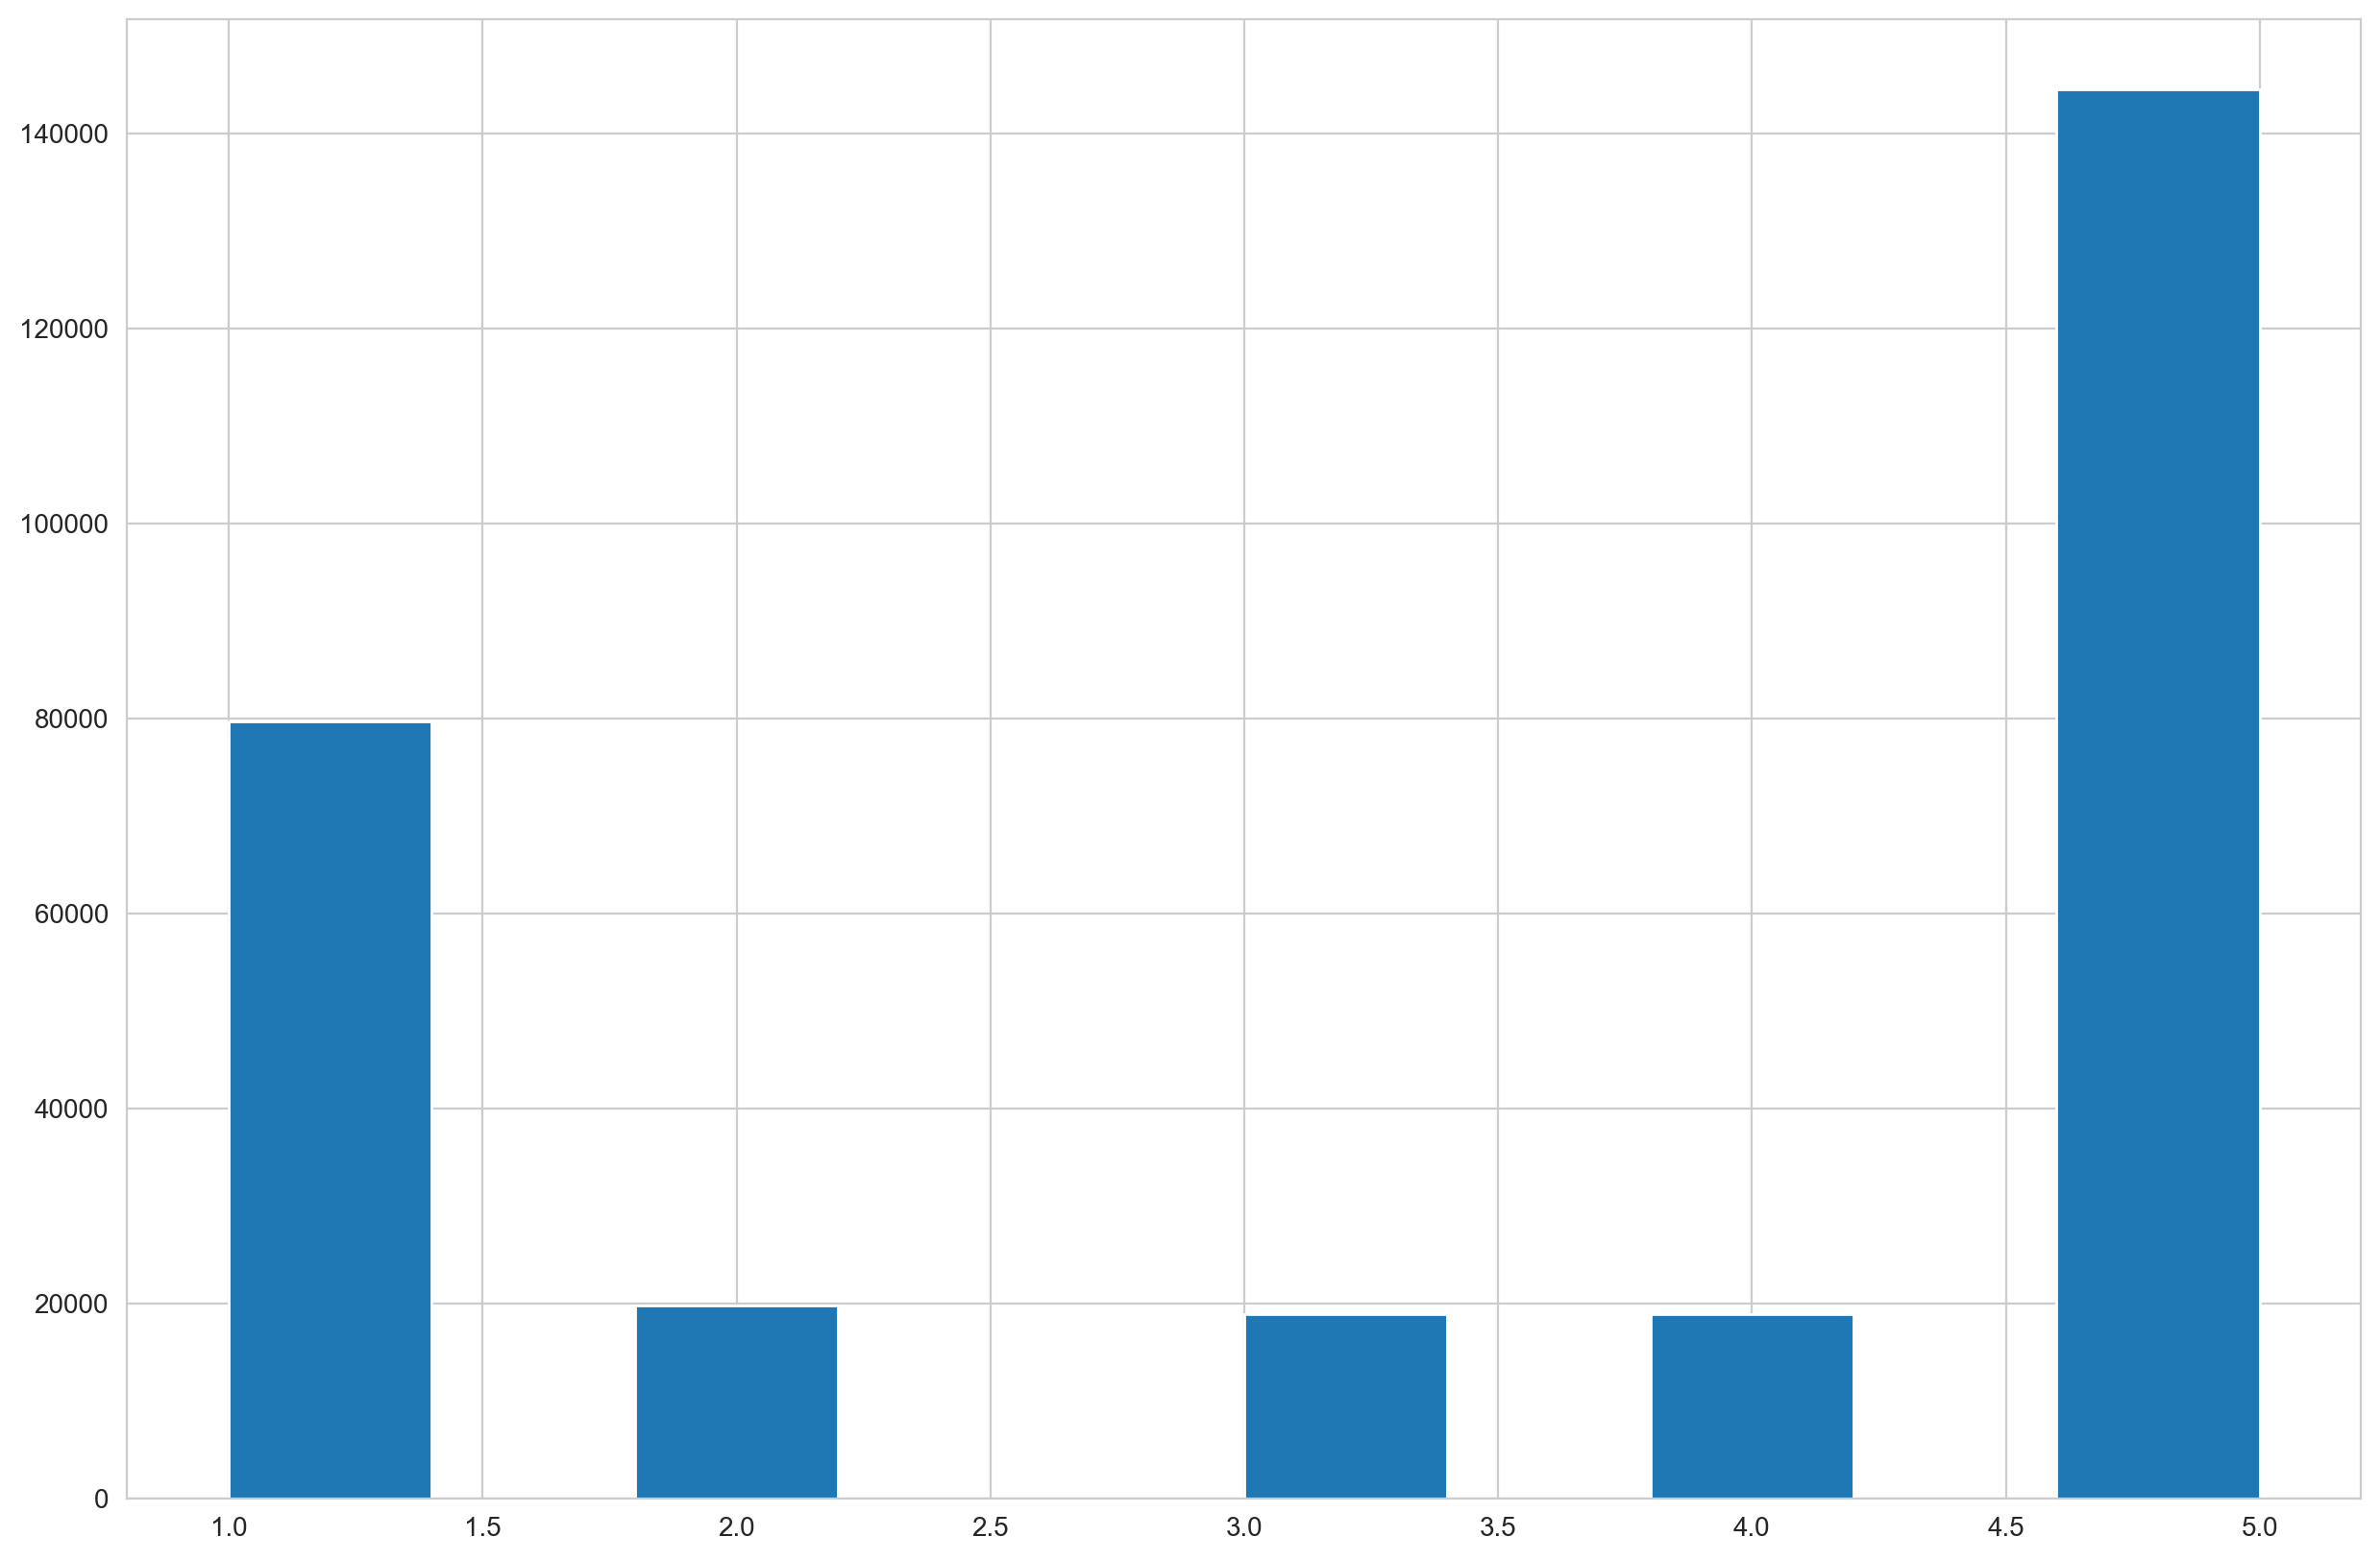

In [19]:
plt.hist(df_stemmed['score'])
plt.show()

## Word Frequency Analysis
Most Frequent Words / Most Common Words

In [20]:
# Function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  # Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # Selecting TOP 20 Most Frequent Words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

C:\Users\Bara\AppData\Local\Temp\ipykernel_37172\131420143.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


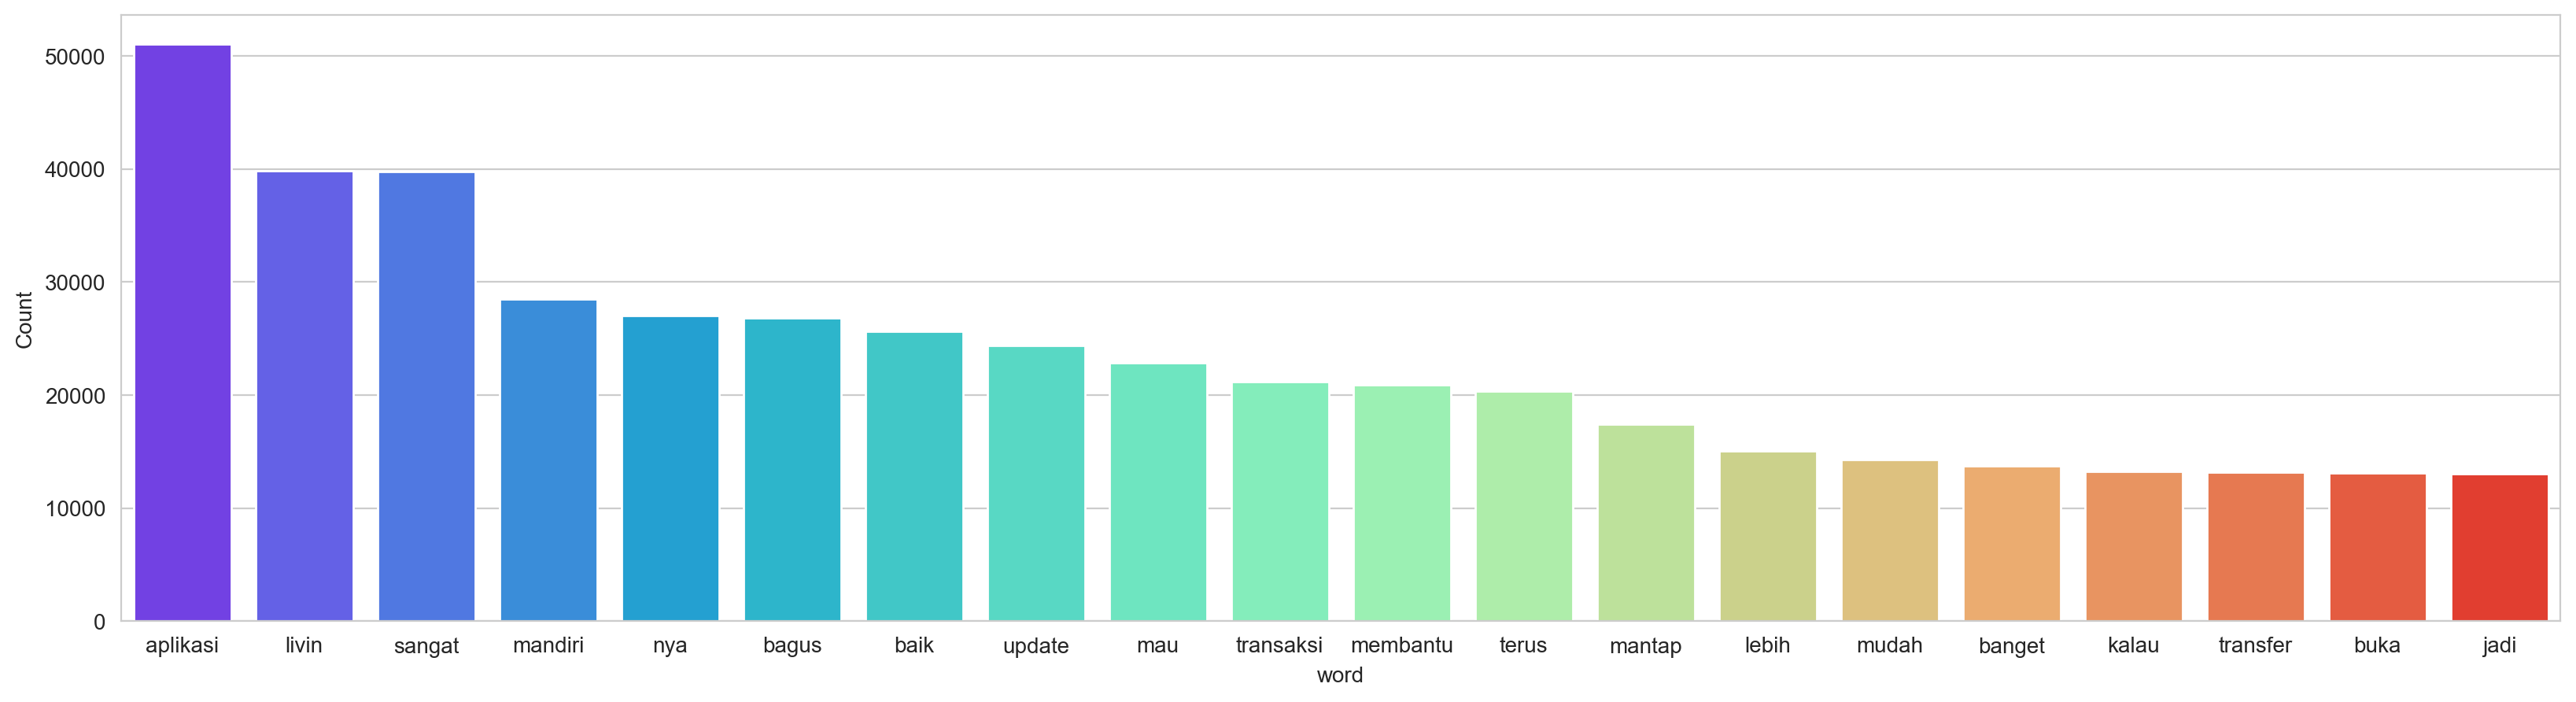

In [21]:
freq_words(df_stemmed['tokens'].apply(lambda x: ' '.join(x)), 20)

## Bag of Words (BoW)

Representasi teks sebagai vektor frekuensi kata menggunakan **CountVectorizer**.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

# Join tokens kembali ke string untuk CountVectorizer
df_stemmed['content_joined'] = df_stemmed['tokens'].apply(lambda x: ' '.join(x))

# Bag of Words
bow_vectorizer = CountVectorizer(max_features=1000)
bow_matrix = bow_vectorizer.fit_transform(df_stemmed['content_joined'])

print("BoW matrix shape:", bow_matrix.shape)
print("(Jumlah review) x (Jumlah fitur/kata unik teratas)\n")

# Top 20 kata paling sering
bow_freq = pd.Series(
    bow_matrix.toarray().sum(axis=0),
    index=bow_vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print("Top 20 kata paling sering (BoW):")
print(bow_freq.head(20))

# Sample DataFrame: tampilkan top 10 kolom paling sering agar tidak semua 0
top10_cols = bow_freq.head(10).index.tolist()
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nSample BoW DataFrame (5 baris, 10 fitur terbanyak):")
bow_df[top10_cols].head(5)

BoW matrix shape: (281691, 1000)
(Jumlah review) x (Jumlah fitur/kata unik teratas)

Top 20 kata paling sering (BoW):
aplikasi     51034
livin        39827
sangat       39792
mandiri      28471
nya          27011
bagus        26828
baik         25639
update       24374
mau          22821
transaksi    21167
membantu     20900
terus        20361
mantap       17432
lebih        15058
mudah        14320
banget       13714
kalau        13243
transfer     13164
buka         13115
jadi         13007
dtype: int64

Sample BoW DataFrame (5 baris, 10 fitur):


,10,100,100rb,10rb,11,12,14,14000,15,20
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


## N-Grams

Analisis kombinasi kata yang muncul berdampingan (Bigram = 2 kata, Trigram = 3 kata).

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.util import ngrams

# --- Bigram (2-gram) ---
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=50)
bigram_matrix = bigram_vectorizer.fit_transform(df_stemmed['content_joined'])
bigram_freq = pd.Series(
    bigram_matrix.toarray().sum(axis=0),
    index=bigram_vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print("Top 20 Bigrams:")
print(bigram_freq.head(20))

# --- Trigram (3-gram) ---
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), max_features=50)
trigram_matrix = trigram_vectorizer.fit_transform(df_stemmed['content_joined'])
trigram_freq = pd.Series(
    trigram_matrix.toarray().sum(axis=0),
    index=trigram_vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print("\nTop 20 Trigrams:")
print(trigram_freq.head(20))

Top 20 Bigrams:
sangat membantu     16281
livin mandiri        9561
aplikasi livin       5452
aplikasi nya         5162
bank mandiri         4151
terima kasih         3880
sangat bagus         3836
gagal terus          3149
lebih mudah          3142
sering error         3025
aplikasi sangat      2752
mobile banking       2580
mau transfer         2464
update terus         2453
minta update         2398
verifikasi wajah     2154
mau login            2140
pakai livin          2079
lebih baik           2061
buka aplikasi        2056
dtype: int64

Top 20 Trigrams:
aplikasi livin mandiri          1446
sangat membantu sekali          1345
aplikasi sangat membantu        1189
bagus sangat membantu            683
sangat membantu transaksi        659
jadi lebih mudah                 601
terima kasih livin               551
livin mandiri sangat             544
minta update terus               488
terlalu sering update            468
aplikasi sangat bagus            407
sangat membantu bertransak